=== Demo: small example ===
Recursive calls: 52
Solution (crew -> list of flight IDs):
{'C1': ['F1', 'F3'], 'C2': ['F2', 'F5'], 'C3': ['F4']}
Total cost: 24.0


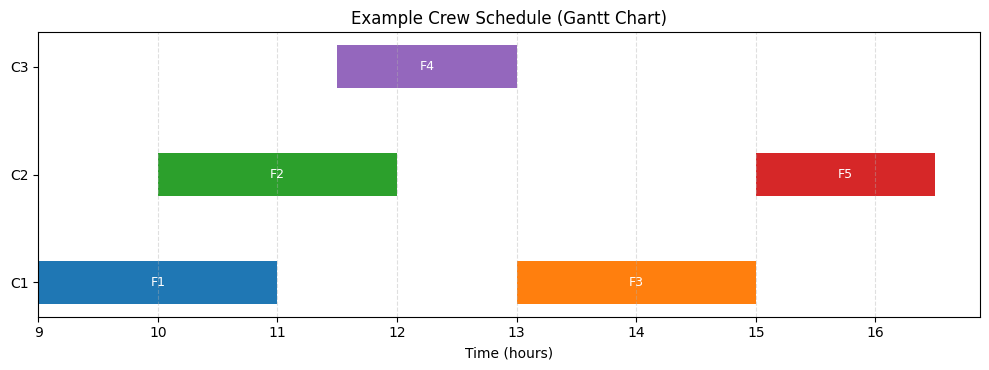


=== Profiling runtime vs n (this may become slow for n > 10) ===
n=4 avg_time=0.0002s avg_calls=66
n=5 avg_time=0.0003s avg_calls=97
n=6 avg_time=0.0004s avg_calls=139
n=7 avg_time=0.0004s avg_calls=115
n=8 avg_time=0.0004s avg_calls=109


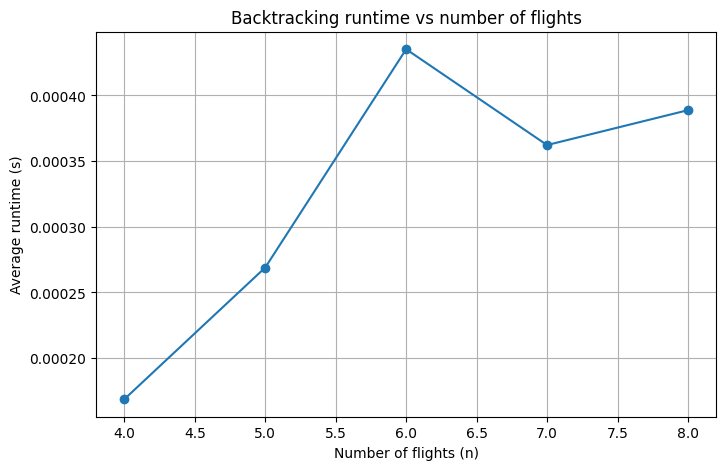

In [1]:
"""Airline Crew Scheduling: backtracking + CSP
Includes:

# 2) Full Python script / notebook cells
Copy everything below into `crew_scheduling.py` or notebook cells.

```python
"""


import itertools
import time
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# PARAMETERS / SAMPLE DATA
# -------------------------
MIN_REST = 1  # minimum rest time in hours between flights for same crew
MINIMIZE_COST = False  # set True to enable cost minimization

# Example flights: (id, start, end)
# times are hours in 24h numeric for simplicity (ints or floats)
flights_example = [
    ('F1', 9, 11),
    ('F2', 10, 12),
    ('F3', 13, 15),
    ('F4', 11.5, 13),  # 11:30 to 13:00
    ('F5', 15, 16.5)
]
crew_members_example = ['C1', 'C2', 'C3']

# Optional cost per (flight,crew) pair — small demo if MINIMIZE_COST True
# If not present, cost defaults to flight duration
example_costs = {
    ('F1', 'C1'): 10, ('F1','C2'): 12, ('F1','C3'): 11,
    ('F2', 'C1'): 8,  ('F2','C2'): 9,  ('F2','C3'): 9,
    # ... fill as needed or the script will use duration
}

# -------------------------
# UTILITIES
# -------------------------
def flight_duration(f):
    return f[2] - f[1]

def flights_by_id(flights):
    return {fid: (fid, s, e) for fid, s, e in flights}

# -------------------------
# CONSTRAINT CHECKER
# -------------------------
def no_conflict(existing_flights, new_flight, min_rest=MIN_REST):
    """
    existing_flights: list of (fid, start, end)
    new_flight: (fid, start, end)
    Returns True if new_flight can be assigned without overlap and with min_rest
    """
    ns, ne = new_flight[1], new_flight[2]
    for _, s, e in existing_flights:
        # check overlap: if intervals intersect considering rest constraints
        # require new start >= e + min_rest OR existing start >= ne + min_rest
        if not (ns >= e + min_rest or s >= ne + min_rest):
            return False
    return True

# -------------------------
# BACKTRACKING ASSIGNER
# -------------------------
class BacktrackingScheduler:
    def __init__(self, flights, crew, costs=None, min_rest=MIN_REST, minimize_cost=False):
        """
        flights: list of (fid, start, end)
        crew: list of crew ids
        costs: dict keyed by (fid, crew) -> cost, optional
        """
        self.flights = flights
        self.crew = crew
        self.min_rest = min_rest
        self.costs = costs or {}
        self.minimize_cost = minimize_cost

        self.best_solution = None
        self.best_cost = float('inf')
        self.calls = 0  # count recursive calls

    def cost_of_assignment(self, assignment):
        # assignment: dict crew->list of flights
        total = 0
        for c, flist in assignment.items():
            for fid in flist:
                key = (fid, c)
                if key in self.costs:
                    total += self.costs[key]
                else:
                    # default cost = flight duration
                    f = next(f for f in self.flights if f[0] == fid)
                    total += flight_duration(f)
        return total

    def solve(self):
        # initial empty assignment
        assignment = {c: [] for c in self.crew}
        remaining = [f for f in self.flights]
        # sort flights by start time heuristic (helps pruning)
        remaining.sort(key=lambda x: x[1])
        self._backtrack(remaining, assignment, 0)
        return self.best_solution, self.best_cost, self.calls

    def _backtrack(self, remaining, assignment, idx):
        self.calls += 1
        # Branch-and-bound: if minimize_cost and current partial cost >= best_cost -> prune
        if self.minimize_cost and self.best_solution is not None:
            partial_cost = self.cost_of_assignment(assignment)
            if partial_cost >= self.best_cost:
                return

        if not remaining:
            # all flights assigned
            total_cost = self.cost_of_assignment(assignment)
            if not self.minimize_cost:
                # if not minimizing cost, first found solution is enough
                if self.best_solution is None:
                    # store mapping with flight IDs
                    self.best_solution = {c: [f for f in flist] for c, flist in assignment.items()}
                    self.best_cost = total_cost
                return
            # if minimizing cost, check best
            if total_cost < self.best_cost:
                self.best_cost = total_cost
                self.best_solution = {c: [f for f in flist] for c, flist in assignment.items()}
            return

        # pick next flight (simple order)
        flight = remaining[0]
        fid = flight[0]

        # try to assign to every crew member
        assigned_flag = False
        for c in self.crew:
            # map current assigned flights for crew to full flight tuples for checking
            assigned_flights_tuples = [next(f for f in self.flights if f[0] == afid) for afid in assignment[c]]
            if no_conflict(assigned_flights_tuples, flight, self.min_rest):
                # assign
                assignment[c].append(fid)
                # recurse on remaining[1:]
                self._backtrack(remaining[1:], assignment, idx+1)
                # unassign
                assignment[c].pop()
                assigned_flag = True

        # If no crew could take this flight, then no feasible assignment down this path
        # prune (dead end)
        if not assigned_flag:
            return

# -------------------------
# GANTT CHART VISUALIZATION
# -------------------------
def plot_gantt(solution, flights, title="Crew Schedule (Gantt Chart)"):
    """
    solution: dict crew -> list of flight IDs (strings)
    flights: list of (fid, start, end)
    """
    # map flight id to start,end
    fmap = {fid: (s,e) for fid, s, e in flights}
    crews = list(solution.keys())
    fig, ax = plt.subplots(figsize=(10, 2 + len(crews)*0.6))
    yticks = []
    ylabels = []
    for i, c in enumerate(crews):
        y = i
        ylabels.append(c)
        yticks.append(y)
        for fid in solution[c]:
            s, e = fmap[fid]
            ax.barh(y, e - s, left=s, height=0.4, align='center')
            ax.text(s + (e-s)/2, y, fid, va='center', ha='center', color='white', fontsize=9)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_xlabel("Time (hours)")
    ax.set_title(title)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# -------------------------
# PROFILING & EXPERIMENTS
# -------------------------
def generate_random_flights(n, start_window=(6, 18), min_dur=1, max_dur=3, allow_overlap=True, seed=None):
    """
    Generate n random flights. If allow_overlap False, tries to make them non-overlapping.
    """
    if seed is not None:
        random.seed(seed)
    flights = []
    for i in range(n):
        if allow_overlap:
            s = round(random.uniform(*start_window), 2)
        else:
            # place deterministically to avoid overlaps: consecutive
            s = start_window[0] + i * (min_dur + MIN_REST)
        dur = round(random.uniform(min_dur, max_dur), 2)
        flights.append((f'F{i+1}', s, s+dur))
    return flights

def profile_runtime_vs_n(crew_members, ns=(4,5,6,7,8,9,10), repeats=3, minimize_cost=False):
    times = []
    calls = []
    for n in ns:
        t_acc = 0.0
        c_acc = 0
        for r in range(repeats):
            flights = generate_random_flights(n, seed=r, allow_overlap=True)
            solver = BacktrackingScheduler(flights, crew_members, min_rest=MIN_REST, minimize_cost=minimize_cost)
            t0 = time.perf_counter()
            sol, cost, calls_count = solver.solve()
            t1 = time.perf_counter()
            t_acc += (t1 - t0)
            c_acc += calls_count
        times.append(t_acc / repeats)
        calls.append(c_acc // repeats)
        print(f"n={n} avg_time={times[-1]:.4f}s avg_calls={calls[-1]}")
    # plot
    plt.figure(figsize=(8,5))
    plt.plot(ns, times, marker='o')
    plt.xlabel("Number of flights (n)")
    plt.ylabel("Average runtime (s)")
    plt.title("Backtracking runtime vs number of flights")
    plt.grid(True)
    plt.show()
    return ns, times, calls

# -------------------------
# DEMO RUN (example)
# -------------------------
if __name__ == "__main__":
    print("=== Demo: small example ===")
    flights = flights_example
    crew = crew_members_example

    scheduler = BacktrackingScheduler(flights, crew, costs=example_costs, min_rest=MIN_REST, minimize_cost=MINIMIZE_COST)
    solution, best_cost, calls = scheduler.solve()

    print("Recursive calls:", calls)
    print("Solution (crew -> list of flight IDs):")
    print(solution)
    print("Total cost:", best_cost)

    if solution:
        plot_gantt(solution, flights, title="Example Crew Schedule (Gantt Chart)")

    # -------------------------
    # Profiling section: runtime vs n
    # -------------------------
    print("\n=== Profiling runtime vs n (this may become slow for n > 10) ===")
    crew_for_profile = ['C1', 'C2', 'C3']
    ns = [4, 5, 6, 7, 8]  # keep small to avoid long runs
    profile_runtime_vs_n(crew_for_profile, ns=ns, repeats=3, minimize_cost=False)
